In [3]:
!pip install tensorflow

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 572.6/572.6 MB 775.5 kB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 57.5/57.5 kB 4.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.9/4.9 MB 125.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 24.5/24.5 MB 92.2 MB/s eta 0:00:00
  Attempting uninstall: h5py
    Found existing installation: h5py 3.16.0
    Uninstalling h5py-3.16.0:
      Successfully uninstalled h5py-3.16.0


In [4]:
import tensorflow as tf
from tensorflow.keras import datasets, layers, models
import matplotlib.pyplot as plt
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
from sklearn.metrics import classification_report, roc_curve, auc
from tensorflow.keras.models import Model
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from sklearn.model_selection import train_test_split
import numpy as np

/usr/local/lib/python3.12/dist-packages/jax/_src/cloud_tpu_init.py:86: UserWarning: Transparent hugepages are not enabled. TPU runtime startup and shutdown time should be significantly improved on TPU v5e and newer. If not already set, you may need to enable transparent hugepages in your VM image (sudo sh -c "echo always > /sys/kernel/mm/transparent_hugepage/enabled")
  warnings.warn(


Dataset loading

In [5]:
(train_images, train_labels), (test_images, test_labels) = datasets.cifar10.load_data()

# normalize pixel values 0-1
train_images, test_images = train_images / 255.0, test_images / 255.0

170498071/170498071 ━━━━━━━━━━━━━━━━━━━━ 4s 0us/step


In [6]:
val_images, test_images, val_labels, test_labels = train_test_split(test_images, test_labels, test_size=0.5, random_state=42)

In [7]:
print(f"Train set: {train_images.shape}, {train_labels.shape}")
print(f"Validation set: {val_images.shape}, {val_labels.shape}")
print(f"Test set: {test_images.shape}, {test_labels.shape}")

Train set: (50000, 32, 32, 3), (50000, 1)
Validation set: (5000, 32, 32, 3), (5000, 1)
Test set: (5000, 32, 32, 3), (5000, 1)


In [8]:
class_names = ['airplane', 'automobile', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck']

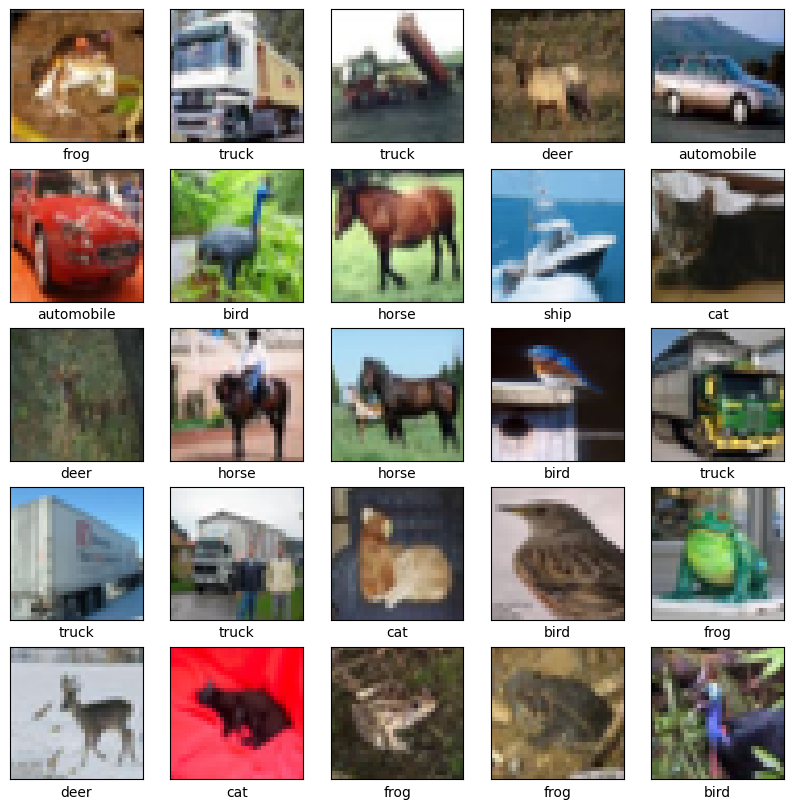

In [9]:
plt.figure(figsize=(10, 10))
for i in range(25):
  plt.subplot(5, 5, i+1)
  plt.xticks([])
  plt.yticks([])
  plt.grid(False)
  plt.imshow(train_images[i])
  plt.xlabel(class_names[train_labels[i][0]])

plt.show()

Shallow CNN Model

In [10]:
model = models.Sequential()
model.add(layers.Input(shape=(32, 32, 3)))
model.add(layers.Conv2D(32, (3, 3), activation='relu'))
model.add(layers.MaxPooling2D((2, 2)))
model.add(layers.Conv2D(64, (3, 3), activation='relu'))
model.add(layers.MaxPooling2D((2, 2)))
model.add(layers.Conv2D(64, (3, 3), activation='relu'))
model.add(layers.Flatten())
model.add(layers.Dense(64, activation='relu'))
model.add(layers.Dense(10))

In [11]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 30, 30, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 15, 15, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 13, 13, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 6, 6, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 4, 4, 64)       │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 1024)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │        65,600 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 122,570 (478.79 KB)

 Trainable params: 122,570 (478.79 KB)

 Non-trainable params: 0 (0.00 B)

In [12]:
shallow_model = models.Sequential([
    layers.Input(shape=(32, 32, 3)), # (32, 32, 3)
    layers.Conv2D(32, (3, 3), activation='relu'), # (32 - 3 + 1) = 30 -> (30, 30, 32)
    layers.MaxPooling2D((2, 2)), # (15, 15, 32)
    layers.Conv2D(64, (3, 3), activation='relu'), # 15 - 3 + 1 = 13 -> (13, 13, 64)
    layers.MaxPooling2D((2, 2)), # (6, 6, 64)
    layers.Conv2D(64, (3, 3), activation='relu'), # 6 - 3 + 1 = 4 -> (4, 4, 64)
    layers.Flatten(), # 4 × 4 × 64 = 1024 -> (1024,)
    layers.Dense(64, activation='relu'), # -> (64,)
    layers.Dense(10) # -> (10,)
])

In [13]:
shallow_model.compile(optimizer='adam', loss=tf.keras.losses.SparseCategoricalCrossentropy(from_logits=True), metrics=['accuracy'])

history_shallow = shallow_model.fit(train_images, train_labels, epochs=5, validation_data=(val_images, val_labels))

Epoch 1/5
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 27s 17ms/step - accuracy: 0.4514 - loss: 1.5144 - val_accuracy: 0.5386 - val_loss: 1.3150
Epoch 2/5
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 28s 18ms/step - accuracy: 0.5856 - loss: 1.1650 - val_accuracy: 0.6070 - val_loss: 1.1044
Epoch 3/5
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 26s 17ms/step - accuracy: 0.6397 - loss: 1.0239 - val_accuracy: 0.6350 - val_loss: 1.0392
Epoch 4/5
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 26s 16ms/step - accuracy: 0.6733 - loss: 0.9324 - val_accuracy: 0.6264 - val_loss: 1.0897
Epoch 5/5
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 25s 16ms/step - accuracy: 0.6956 - loss: 0.8568 - val_accuracy: 0.6708 - val_loss: 0.9416


Deep CNN Model

In [14]:
deep_model = models.Sequential([
    layers.Input(shape=(32, 32, 3)),

    layers.Conv2D(32, (3, 3), activation='relu', padding='same'),
    layers.Conv2D(64, (3, 3), activation='relu', padding='same'),
    layers.MaxPooling2D((2, 2)), # Output: (16, 16, 64)

    layers.Conv2D(128, (3, 3), activation='relu', padding='same'),
    layers.Conv2D(128, (3, 3), activation='relu', padding='same'),
    layers.MaxPooling2D((2, 2)), # (8, 8, 128)

    layers.Conv2D(256, (3, 3), activation='relu', padding='same'),
    layers.Conv2D(256, (3, 3), activation='relu', padding='same'),
    layers.MaxPooling2D((2, 2)), # (4, 4, 256)

    layers.Flatten(),
    layers.Dense(256, activation='relu'),
    layers.Dropout(0.5),
    layers.Dense(10)
])

In [15]:
deep_model.compile(optimizer='adam', loss=tf.keras.losses.SparseCategoricalCrossentropy(from_logits=True), metrics=['accuracy'])

history_deep = deep_model.fit(train_images, train_labels, epochs=5, validation_data=(val_images, val_labels))

Epoch 1/5
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 389s 248ms/step - accuracy: 0.3868 - loss: 1.6531 - val_accuracy: 0.5282 - val_loss: 1.3217
Epoch 2/5
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 361s 231ms/step - accuracy: 0.6013 - loss: 1.1299 - val_accuracy: 0.6772 - val_loss: 0.9127
Epoch 3/5
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 360s 230ms/step - accuracy: 0.6881 - loss: 0.8988 - val_accuracy: 0.7086 - val_loss: 0.8155
Epoch 4/5
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 361s 231ms/step - accuracy: 0.7330 - loss: 0.7681 - val_accuracy: 0.7292 - val_loss: 0.7949
Epoch 5/5
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 357s 228ms/step - accuracy: 0.7668 - loss: 0.6750 - val_accuracy: 0.7530 - val_loss: 0.7191


Comparison Shallow vs Deep CNN

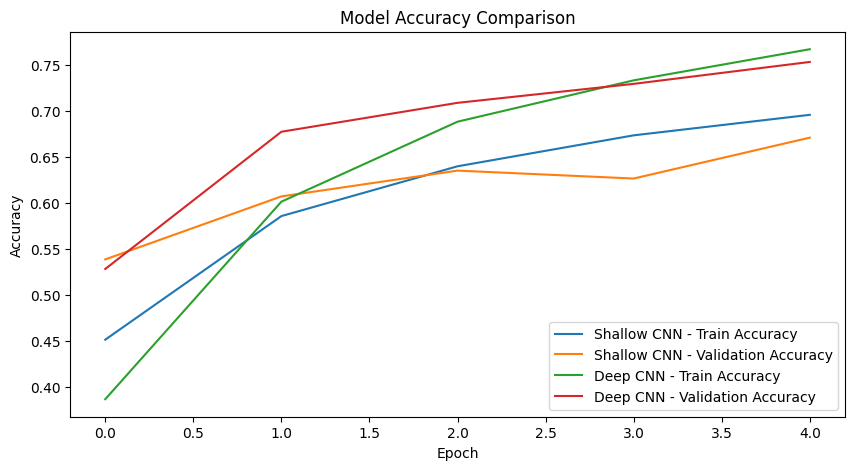

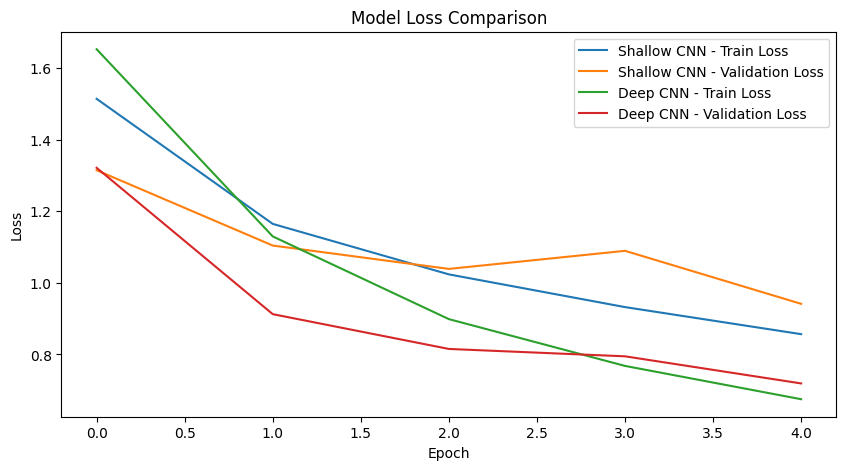

In [17]:
plt.figure(figsize=(10, 5))
plt.plot(history_shallow.history['accuracy'], label='Shallow CNN - Train Accuracy')
plt.plot(history_shallow.history['val_accuracy'], label='Shallow CNN - Validation Accuracy')
plt.plot(history_deep.history['accuracy'], label='Deep CNN - Train Accuracy')
plt.plot(history_deep.history['val_accuracy'], label='Deep CNN - Validation Accuracy')
plt.title('Model Accuracy Comparison')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.show()

plt.figure(figsize=(10, 5))
plt.plot(history_shallow.history['loss'], label='Shallow CNN - Train Loss')
plt.plot(history_shallow.history['val_loss'], label='Shallow CNN - Validation Loss')
plt.plot(history_deep.history['loss'], label='Deep CNN - Train Loss')
plt.plot(history_deep.history['val_loss'], label='Deep CNN - Validation Loss')
plt.title('Model Loss Comparison')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.show()

Evaluate Models

In [18]:
shallow_test_loss, shallow_test_acc = shallow_model.evaluate(test_images, test_labels, verbose=1)
deep_test_loss, deep_test_acc = deep_model.evaluate(test_images, test_labels, verbose=1)

print(f'Shallow CNN Test Accuracy: {shallow_test_acc:.4f}')
print(f'Deep CNN Test Accuracy: {deep_test_acc:.4f}')

if deep_test_acc > shallow_test_acc:
  print("\nDeep CNN is better, higher accuracy")
  better_model='Deep CNN'
  better_accuracy = deep_test_acc
else:
  print("\Shallow CNN is better, higher accuracy")
  better_model='Shallow CNN'
  better_accuracy = shallow_test_acc

print(f"Better Model: {better_model} with Accuracy: {better_accuracy:.4f}")

 25/157 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.6639 - loss: 0.9586 

<>:12: SyntaxWarning: invalid escape sequence '\S'
<>:12: SyntaxWarning: invalid escape sequence '\S'
/tmp/ipykernel_2856/1819182711.py:12: SyntaxWarning: invalid escape sequence '\S'
  print("\Shallow CNN is better, higher accuracy")


157/157 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.6642 - loss: 0.9641
157/157 ━━━━━━━━━━━━━━━━━━━━ 9s 59ms/step - accuracy: 0.7486 - loss: 0.7559
Shallow CNN Test Accuracy: 0.6642
Deep CNN Test Accuracy: 0.7486

Deep CNN is better, higher accuracy
Better Model: Deep CNN with Accuracy: 0.7486


Missclassified Images

In [19]:
predictions = np.argmax(deep_model.predict(test_images), axis=1)
true_labels = test_labels.flatten()

157/157 ━━━━━━━━━━━━━━━━━━━━ 9s 60ms/step


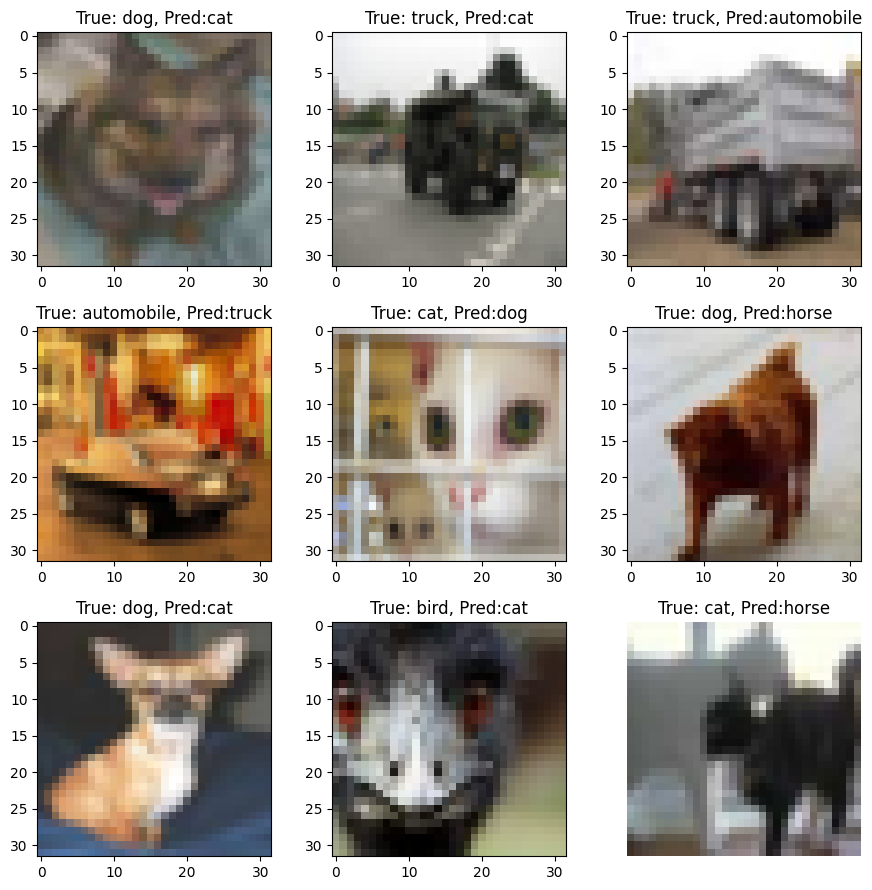

In [20]:
missclassified_idx = np.where(predictions != true_labels)[0]
fig, axes = plt.subplots(3, 3, figsize=(9, 9))

for i, ax in enumerate(axes.flat):
  idx = missclassified_idx[i]
  ax.imshow(test_images[idx])
  ax.set_title(f'True: {class_names[true_labels[idx]]}, Pred:{class_names[predictions[idx]]}')
  plt.axis('off')
plt.tight_layout()
plt.show()

157/157 ━━━━━━━━━━━━━━━━━━━━ 9s 60ms/step
              precision    recall  f1-score   support

    airplane       0.72      0.82      0.77       479
  automobile       0.85      0.92      0.88       486
        bird       0.75      0.60      0.67       525
         cat       0.54      0.66      0.59       500
        deer       0.72      0.64      0.68       506
         dog       0.57      0.75      0.65       478
        frog       0.83      0.78      0.80       511
       horse       0.87      0.70      0.78       528
        ship       0.89      0.81      0.85       489
       truck       0.91      0.81      0.86       498

    accuracy                           0.75      5000
   macro avg       0.76      0.75      0.75      5000
weighted avg       0.76      0.75      0.75      5000



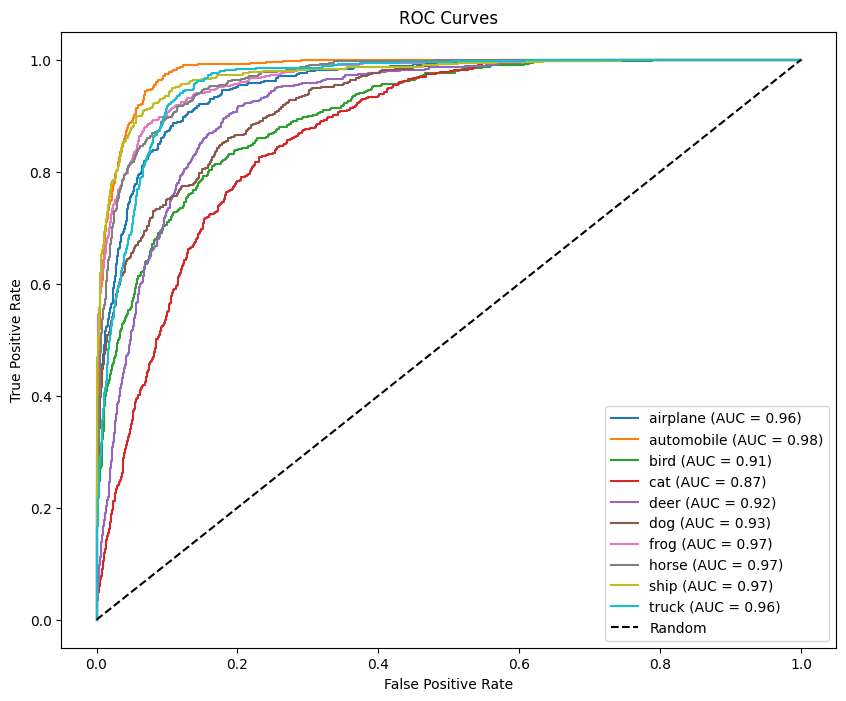

In [24]:
predictions_prob = deep_model.predict(test_images)
predictions = np.argmax(predictions_prob, axis=1)

print(classification_report(true_labels, predictions, target_names=class_names))

plt.figure(figsize=(10, 8))
for i in range(10):
  fpr, tpr, _ = roc_curve(true_labels == i, predictions_prob[:, i])
  roc_auc = auc(fpr, tpr)
  plt.plot(fpr, tpr, label=f'{class_names[i]} (AUC = {roc_auc:.2f})')

plt.plot([0, 1], [0, 1], 'k--', label='Random')
plt.title('ROC Curves')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.legend(loc='lower right')
plt.show()

# Overall Performance

* **Accuracy: 0.75**
  → The model gets **75% of predictions correct**.

* **Macro avg (F1 ≈ 0.75)**
  → Treats all classes equally → performance is **fairly balanced across classes**.

* **Weighted avg (F1 ≈ 0.75)**
  → Accounts for class frequency → since it’s similar to macro, your dataset is **well balanced** (which matches the supports ~500 per class).

# Class-by-Class Insights

## Strong Classes (High precision & recall)

These are your best-performing categories:

* **automobile (F1 = 0.88)**
* **truck (F1 = 0.86)**
* **ship (F1 = 0.85)**
* **frog (F1 = 0.80)**

## Good but improvable

* airplane (0.77)
* horse (0.78)

Observations:

* **Horse recall (0.70)** is lower → model **misses horses often**
* airplane is relatively balanced

---

## Weak Classes (Problem Areas)

### cat (F1 = 0.59)

* Precision: 0.54 (lots of false positives)
* Recall: 0.66

Observations:

* Often **wrong when predicting "cat"**

---

### dog (F1 = 0.65)

* Precision: 0.57 (bad)
* Recall: 0.75 (good)

Observations:

* **Over-predicts dog**
* Many **non-dogs classified as dogs**

---

### bird (F1 = 0.67)

* Recall: **0.60 (low)**

Observations:

* **Misses many birds**

---

### deer (F1 = 0.68)

* Balanced but mediocre

---

# Key Patterns

### 1. Animal confusion problem

Classes with biggest issues:

* cat, dog, deer, bird

These share:

* Similar textures (fur, nature backgrounds)
* Similar shapes

---

### 2. Vehicles are easy

* automobile, truck, ship perform very well

* Strong structural differences
* Less overlap between categories

---

### 3. Precision vs Recall imbalance

Example:

* **dog:** high recall, low precision → overprediction
* **bird:** low recall → under-detection


* Model **bias toward certain classes**

---

# What We Could Improve

## Better feature discrimination for animals

Try:

* Data augmentation (especially for animals)
* Higher resolution inputs
* Stronger architectures (ResNet, EfficientNet)

---